# 探索性的数据分析

2026/3/7

## 电池的数据(以b0005为例)

In [2]:
import scipy.io

# 假设我们先查看第一个文件夹里的某一个电池数据，比如 B0005.mat

file_path = r"C:\Users\PLUTO\Desktop\battery-rul\data\raw\1. BatteryAgingARC-FY08Q4\B0005.mat"

# 读取数据
mat_data = scipy.io.loadmat(file_path)

# 查看读取出来的字典包含了哪些键
print(mat_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'B0005'])


我们可以看到：因为这个文件叫 B0005.mat，所以当时保存数据的人（NASA 的研究员）把所有的电池充放电数据都打包塞在了一个名为 B0005 的变量里。
在 MATLAB 转换到 Python (scipy) 的过程中，复杂的数据结构通常会被转换成嵌套的 Numpy 数组（Numpy arrays）。NASA 的这个数据集出了名的嵌套得很深（就像俄罗斯套娃一样）。

In [3]:
# 提取核心数据
battery_data = mat_data['B0005']

# 查看数据的类型
print("数据类型:", type(battery_data))

# 查看数据的形状 (Shape)
print("数据形状:", battery_data.shape)

数据类型: <class 'numpy.ndarray'>
数据形状: (1, 1)


提取出了一个numpy结构，我们需要看一看具体有哪些的列名：

In [4]:
# 剥开第一层套娃，提取真正的结构体
core_struct = battery_data[0, 0]

# 在 Numpy 的结构化数组中，字段名存在 dtype.names 里
print("这一层包含的字段有:", core_struct.dtype.names)

这一层包含的字段有: ('cycle',)


提出来的字段名为： cycle。 说明充放电的所有数据被组合进了这个一个字段中

In [5]:
# 提取所有的循环数据
cycles = core_struct['cycle'][0]

print(f"这块电池一共经历了 {len(cycles)} 个测试阶段。")

# 我们拿第一个测试阶段（索引为0）来看看它里面记录了什么
first_cycle = cycles[0]
print("单个测试阶段包含的字段有:", first_cycle.dtype.names)

# 我们再看看第一个测试阶段具体是什么类型的测试
test_type = first_cycle['type'][0]
print("第一个测试阶段的类型是:", test_type)

这块电池一共经历了 616 个测试阶段。
单个测试阶段包含的字段有: ('type', 'ambient_temperature', 'time', 'data')
第一个测试阶段的类型是: charge


数据说明：我们提取的mat_data中所有的数据都被打包进了一个叫'b0005'的字典字段值中。这个key的值是一个（1，1）的ndarray，我们使用core_struct得到了它。这个core它们实际上是 Numpy 的结构化数组 (Structured Arrays)。有一个'cycle'字段，它对应的值是一个长度为616的大列表，每个元素是也是一个结构化数组，包含着('type', 'ambient_temperature', 'time', 'data')。

In [8]:
# 第一个 "charge" 阶段
first_charge_cycle = cycles[0]

print(f"该测试阶段类型是：{first_charge_cycle['type'][0]}")

charge_data = first_charge_cycle['data'][0,0]

print(f"具体的物理量有：{charge_data.dtype.names}")

该测试阶段类型是：charge
具体的物理量有：('Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_charge', 'Voltage_charge', 'Time')


值得注意的是充电的过程中没有 capacity

In [7]:
# 遍历 616 个测试阶段，找到第一个 "discharge" (放电) 阶段
for i in range(len(cycles)):
    # 提取当前阶段的类型
    current_type = cycles[i]['type'][0] 
    
    if current_type == 'discharge':
        first_discharge_index = i
        first_discharge_cycle = cycles[i]
        break

print(f"第一个放电阶段出现在索引: {first_discharge_index}")

# 提取放电阶段中的 'data' (这里通常还有最后一层套娃)
discharge_data = first_discharge_cycle['data'][0, 0]

# 查看里面有哪些具体的物理指标
print("放电阶段包含的具体物理量有:", discharge_data.dtype.names)

第一个放电阶段出现在索引: 1
放电阶段包含的具体物理量有: ('Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time', 'Capacity')


我们已经知道放电过程中具体的物理量包括：电压、电流、温度、负载端的电压和电流、时间戳和容量

In [26]:
# 准备一个空字典来计数
cycle_counts = {'charge': 0, 'discharge': 0, 'impedance': 0, 'other': 0}

# 遍历 B0005 的所有 616 个测试阶段
for i in range(len(cycles)):
    current_type = cycles[i]['type'][0]
    
    if current_type in cycle_counts:
        cycle_counts[current_type] += 1 
    else:
        cycle_counts['other'] += 1

print("B0005 电池生命周期内的测试阶段统计：")
for k, v in cycle_counts.items():
    print(f"- {k.capitalize()} (测试): {v} 次")

print(f"总计: {sum(cycle_counts.values())} 次")

B0005 电池生命周期内的测试阶段统计：
- Charge (测试): 170 次
- Discharge (测试): 168 次
- Impedance (测试): 278 次
- Other (测试): 0 次
总计: 616 次


NASA 数据集里的第三种测试类型：阻抗测试 (impedance)。在 NASA 的实验设计中，研究员们并不仅仅是枯燥地给电池“充电-放电-充电-放电”。为了更深度地窥探电池内部的老化情况，他们会定期停下来，测试其中的电阻。

## 绘图

In [11]:
# --- 解决中文乱码的关键代码 ---
# 设置为黑体 (SimHei) 或 微软雅黑 (Microsoft YaHei)
plt.rcParams['font.sans-serif'] = ['SimHei'] 
# 解决坐标轴负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

### 放电容量数据图

成功提取了 168 个放电容量数据点！


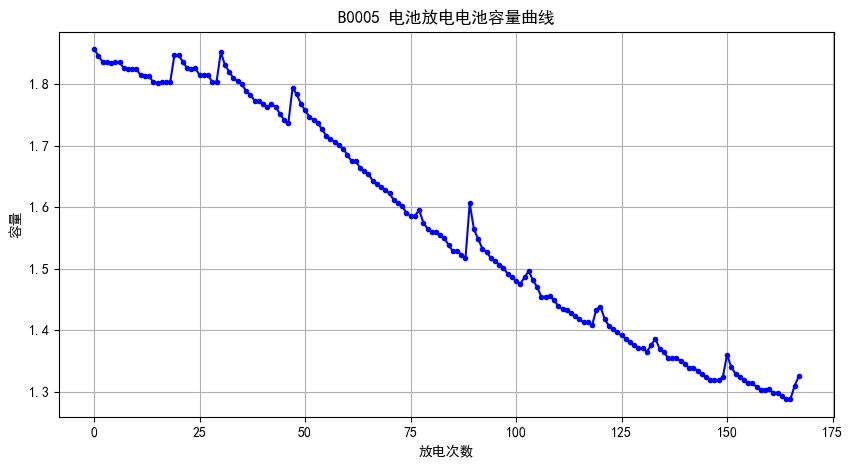

In [12]:
import matplotlib.pyplot as plt

# 准备一个空列表，用来装每一次放电的容量
capacities = []

for i in range(len(cycles)):
    current_cycle = cycles[i]
    current_type = current_cycle['type'][0]

    if current_type == 'discharge':
        current_data = current_cycle['data'][0, 0]

        capacity_value = current_data['Capacity'][0, 0]
        capacities.append(capacity_value)

print(f"成功提取了 {len(capacities)} 个放电容量数据点！")

# 画图

plt.figure(figsize=(10, 5))
plt.plot(capacities, marker='.', linestyle='-', color='b')
plt.title("B0005 电池放电电池容量曲线")
plt.xlabel("放电次数")
plt.ylabel("容量")
plt.grid(True)
plt.show()

- 整体退化趋势（Aging Trend）：随着放电循环次数的增加，电池容量从初始的约 1.85 Ah 呈现出明显的非线性下降趋势，最终跌至 1.3 Ah 左右。这直观地反映了电池内部活性物质的损耗和健康状态（State of Health, SOH）的持续衰退。
- 容量恢复效应（Capacity Regeneration）：值得注意的是，退化曲线并非平滑下降，而是伴随着多次明显的“局部反弹”尖峰（例如在第 20、50、90、150 次循环附近）。这种现象在电池领域被称为“容量恢复现象”或“自恢复效应”。它通常发生在电池经历了较长时间的静置休息后，内部化学物质扩散达到新的平衡，从而在随后的循环中表现出可用容量的短暂回升。

### 充电过程数据图

恒流阶段 (CC, Constant Current)：一开始，用固定的最大电流猛充，电压会快速上升。

恒压阶段 (CV, Constant Voltage)：当电压达到上限（比如 4.2V）时，保持电压不变，电流开始慢慢减小，直到充满。

随着电池老化，电池的内阻会变大：老化的电池：稍微一充，电压就“虚高”到了上限，导致它很早就被迫进入“恒压小电流”阶段。

$$ R = {U}/{I} $$

总共找到 170 个充电阶段。


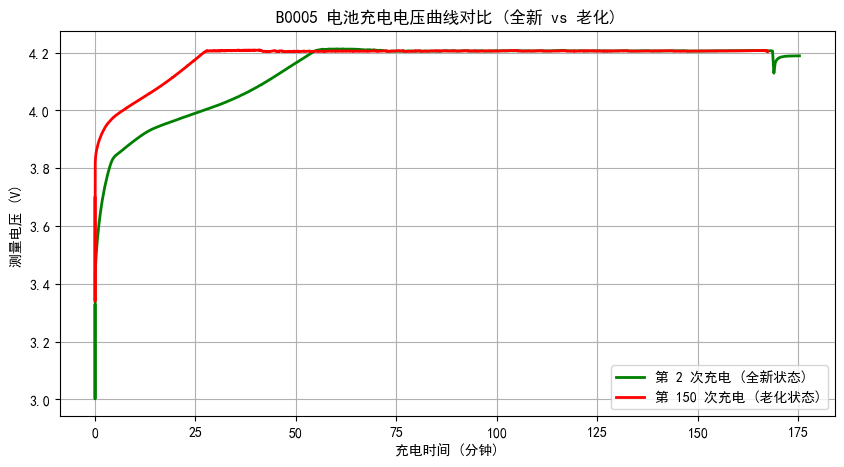

In [24]:
import matplotlib.pyplot as plt

# 1. 提取所有的充电(charge)阶段数据
charge_cycles = []
for i in range(len(cycles)):
    if cycles[i]['type'][0] == 'charge':
        charge_cycles.append(cycles[i])

print(f"总共找到 {len(charge_cycles)} 个充电阶段。")

# 2. 提取第 2 次充电（全新电池）的数据
# 注意：数组索引从 0 开始
data_cycle_1 = charge_cycles[1]['data'][0, 0]
time_1 = data_cycle_1['Time'][0] / 60  # 将秒转换为分钟
voltage_1 = data_cycle_1['Voltage_measured'][0]

# 3. 提取第 150 次充电（老化电池）的数据
# 假设我们取第 150 次充电（索引为 149）
data_cycle_150 = charge_cycles[149]['data'][0, 0]
time_150 = data_cycle_150['Time'][0] / 60
voltage_150 = data_cycle_150['Voltage_measured'][0]

# 4. 开始画图
plt.figure(figsize=(10, 5))

# 画第 1 次循环的电压曲线（绿色代表健康）
plt.plot(time_1, voltage_1, label='第 2 次充电 (全新状态)', color='green', linewidth=2)

# 画第 150 次循环的电压曲线（红色代表老化）
plt.plot(time_150, voltage_150, label='第 150 次充电 (老化状态)', color='red', linewidth=2)

plt.title("B0005 电池充电电压曲线对比 (全新 vs 老化)")
plt.xlabel("充电时间 (分钟)")
plt.ylabel("测量电压 (V)")
plt.legend() # 显示图例标注
plt.grid(True)
plt.show()

# 不同电池组的数据分析

本数据集一共有38块电池充放电的数据，分成了6组。

In [25]:
import os

# 指向包含这 6 个子文件夹的根目录
raw_data_dir = r'../data/raw'

total_batteries = 0
battery_files = []

# 遍历 raw 目录下的所有子文件夹和文件
for root, dirs, files in os.walk(raw_data_dir):
    for file in files:
        # 只统计 .mat 文件
        if file.endswith('.mat'):
            total_batteries += 1
            battery_files.append(file)

print(f"一共找到了 {total_batteries} 块电池的数据文件。")

# 打印前 10 个文件名看看
print("前 10 块电池的文件名是:", battery_files[:10])

扫描完毕！一共找到了 38 块电池的数据文件。
前 10 块电池的文件名是: ['B0005.mat', 'B0006.mat', 'B0007.mat', 'B0018.mat', 'B0025.mat', 'B0026.mat', 'B0027.mat', 'B0028.mat', 'B0025.mat', 'B0026.mat']


## 第一组电池数据分析

一组四个锂离子电池（编号 5、6、7 和 18）在室温下进行了三种不同的操作模式（充电、放电和阻抗测试）。

充电以 1.5A 的恒流 (CC) 模式进行，直到电池电压达到 4.2V，然后继续以恒压 (CV) 模式进行，直到充电电流降至 20mA 。

放电以 2A 的恒流 (CC) 水平进行，直到电池 5、6、7 和 18 的电压分别降至 2.7V、2.5V、2.2V 和 2.5V 。

阻抗测量通过从 0.1Hz 到 5kHz 的电化学阻抗谱 (EIS) 频率扫描进行 。

反复的充放电循环会导致电池加速老化，而阻抗测量则提供了随着老化进行而发生变化的电池内部参数的深入信息 。

当电池达到寿命终止 (EOL, End-of-Life) 标准时，即额定容量衰减 30%（从 2Ahr 降至 1.4Ahr），实验即告停止 。

该数据集可用于预测剩余电量（针对给定的放电循环）和剩余使用寿命 (RUL) 。

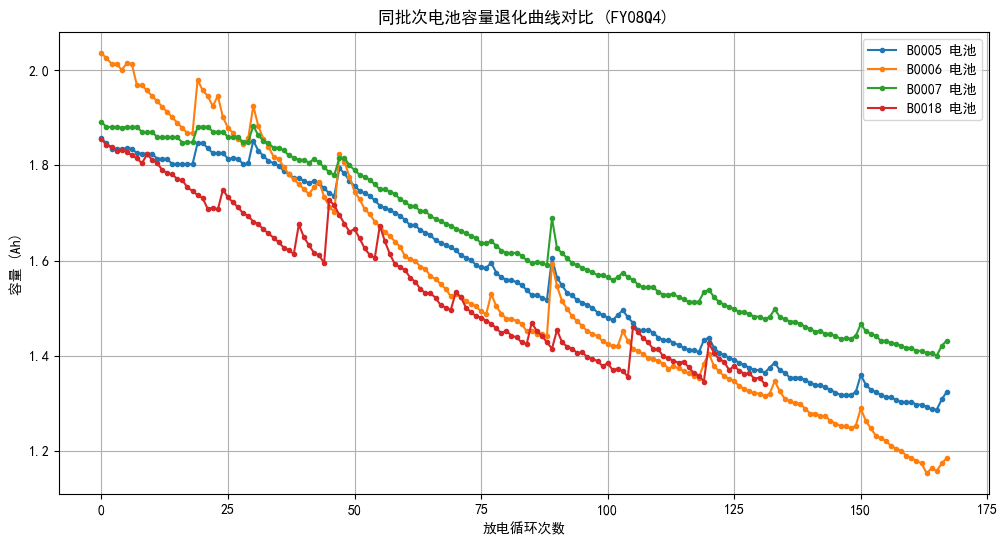

In [27]:
import os
import scipy.io
import matplotlib.pyplot as plt

# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 

def extract_capacity(file_path):
    """
    通用函数：输入 .mat 文件路径，自动返回电池名称和容量列表

    - file_fath: your file path
    """
    mat_data = scipy.io.loadmat(file_path)
    
    battery_name = [k for k in mat_data.keys() if not k.startswith('__')][0]
    
    battery_data = mat_data[battery_name]
    cycles = battery_data[0, 0]['cycle'][0]
    
    capacities = []
    for i in range(len(cycles)):
        if cycles[i]['type'][0] == 'discharge':
            data_struct = cycles[i]['data'][0, 0]
            # 提取容量
            cap = data_struct['Capacity'][0, 0]
            capacities.append(cap)
            
    return battery_name, capacities

# ----------------- 批量处理逻辑 -----------------

folder_path = r'../data/raw/1. BatteryAgingARC-FY08Q4'

plt.figure(figsize=(12, 6))

# 遍历文件夹里的每一个文件
for file_name in os.listdir(folder_path):
    # 只处理 .mat 结尾的文件
    if file_name.endswith('.mat'):
        # 拼出完整的文件路径
        file_path = os.path.join(folder_path, file_name)
        
        batt_name, caps = extract_capacity(file_path)
        
        # 画入同一张图中
        plt.plot(caps, marker='.', label=f'{batt_name} 电池')

plt.title('同批次电池容量退化曲线对比 (FY08Q4)')
plt.xlabel('放电循环次数')
plt.ylabel('容量 (Ah)')
plt.legend() 
plt.grid(True)
plt.show()

## 第二组电池数据分析

一组四个锂离子电池（编号 25、26、27 和 28）在室温（24°C）下进行了三种不同的操作模式（充电、放电和阻抗测试） 。

充电以 1.5A 的恒流 (CC) 模式进行，直到电池电压达到 4.2V，然后继续以恒压 (CV) 模式进行，直到充电电流降至 20mA 。

**核心差异**放电使用频率为 0.05Hz、振幅为 4A、占空比为 50% 的方波负载进行，直到电池 25、26、27 和 28 的电压分别降至 2.0V、2.2V、2.5V 和 2.7V

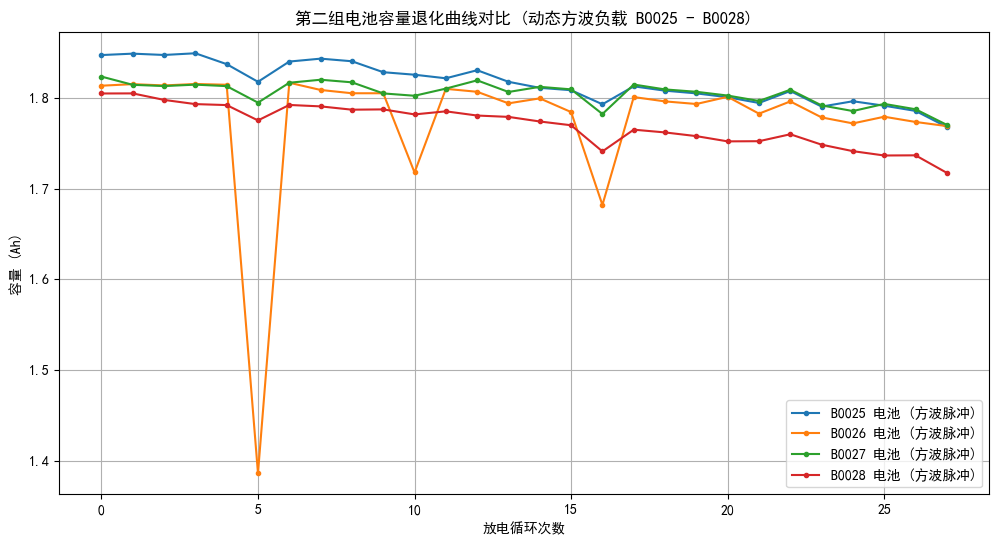

In [29]:
# 指向第二组的文件夹路径（注意这里的 _P1 后缀）
folder_path_group2 = r'../data/raw/2. BatteryAgingARC_25_26_27_28_P1'

plt.figure(figsize=(12, 6))

# 遍历第二组文件夹里的每一个文件
for file_name in os.listdir(folder_path_group2):
    # 自动过滤掉非 .mat 文件（如果有的话）
    if file_name.endswith('.mat'):
        file_path = os.path.join(folder_path_group2, file_name)
        
        batt_name, caps = extract_capacity(file_path)
        
        # 画入同一张图中
        plt.plot(caps, marker='.', label=f'{batt_name} 电池 (方波脉冲)')

plt.title('第二组电池容量退化曲线对比 (动态方波负载 B0025 - B0028)')
plt.xlabel('放电循环次数')
plt.ylabel('容量 (Ah)')
plt.legend()
plt.grid(True)
plt.show()

## 第三组电池数据分析

### 29-32号电池数据分析

一组由四个锂离子电池（#29、#30、#31 和 #32）组成的电池在 较高环境温度 43°C 条件下进行了三种不同运行工况的测试，包括充电、放电以及阻抗测量。充电过程首先采用 恒流（CC）模式，以 1.5A 的电流进行充电，直到电池电压达到 4.2V；随后转入 恒压（CV）模式，并持续充电，直到充电电流下降到 20mA 为止。

放电测试以 4A 的电流进行，直到电池电压下降至各自的截止电压为止。其中，电池 29 的截止电压为 2.0V，电池 30 为 2.2V，电池 31 为 2.5V，电池 32 为 2.7V。此外，实验还进行了阻抗测量，通过 电化学阻抗谱（EIS） 方法，在 0.1Hz 至 5kHz 的频率范围内进行频率扫描。

四块电池（29-32号）在 43°C 的高温环境下运行 。充电采用标准 CC-CV 模式（1.5A 充至 4.2V） 。放电电流统一为 4A，截止电压分别为 2.0V, 2.2V, 2.5V, 2.7V 。高温会显著加速电池内部的化学副反应，如电解液分解。在 $T = 43°C$ 且大电流 $I = 4A$ 的共同作用下，电池的 Arrhenius 速率常数 $k$ 增大：$$k = A e^{-\frac{E_a}{RT}}$$这意味着这组电池的容量衰减斜率会比第一组（24°C）陡峭得多。

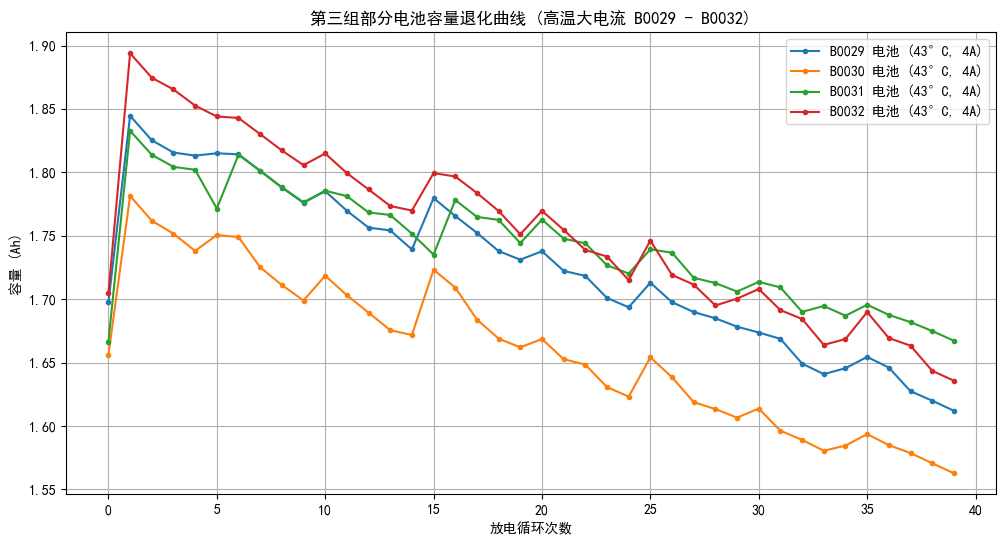

In [30]:
# 指向第 3 个文件夹路径
folder_path_group3 = r'../data/raw/3. BatteryAgingARC_25-44'

# 定义我们要绘制的具体电池编号
target_batteries = ['B0029.mat', 'B0030.mat', 'B0031.mat', 'B0032.mat']

plt.figure(figsize=(12, 6))

for file_name in target_batteries:
    file_path = os.path.join(folder_path_group3, file_name)
    
    # 检查文件是否存在（防止路径引用错误）
    if os.path.exists(file_path):
        batt_name, caps = extract_capacity(file_path)
        plt.plot(caps, marker='.', label=f'{batt_name} 电池 (43°C, 4A)')
    else:
        print(f"警告：找不到文件 {file_name}")

plt.title('第三组部分电池容量退化曲线 (高温大电流 B0029 - B0032)')
plt.xlabel('放电循环次数')
plt.ylabel('容量 (Ah)')
plt.legend()
plt.grid(True)
plt.show()

### 33-36号电池数据分析

一组由三个锂离子电池（#33、#34 和 #36）组成的电池在 室温（24°C） 条件下进行了三种不同运行工况的测试，包括充电、放电以及阻抗测量。充电过程首先采用 恒流（CC）模式，以 1.5A 的电流进行充电，直到电池电压达到 4.2V；随后转入 恒压（CV）模式，并持续充电，直到充电电流下降到 20mA 为止。

在放电测试中，电池 33 和 34 以 4A 的电流进行放电，直到电压分别下降至 2.0V 和 2.2V。而电池 36 则以 2A 的电流进行放电，直到电压下降至 2.7V。此外，实验还进行了阻抗测量，通过 电化学阻抗谱（EIS） 方法，在 0.1Hz 至 5kHz 的频率范围内进行频率扫描。

整个实验持续进行，直到电池容量下降至 1.6Ah（即容量衰减 20%）为止。

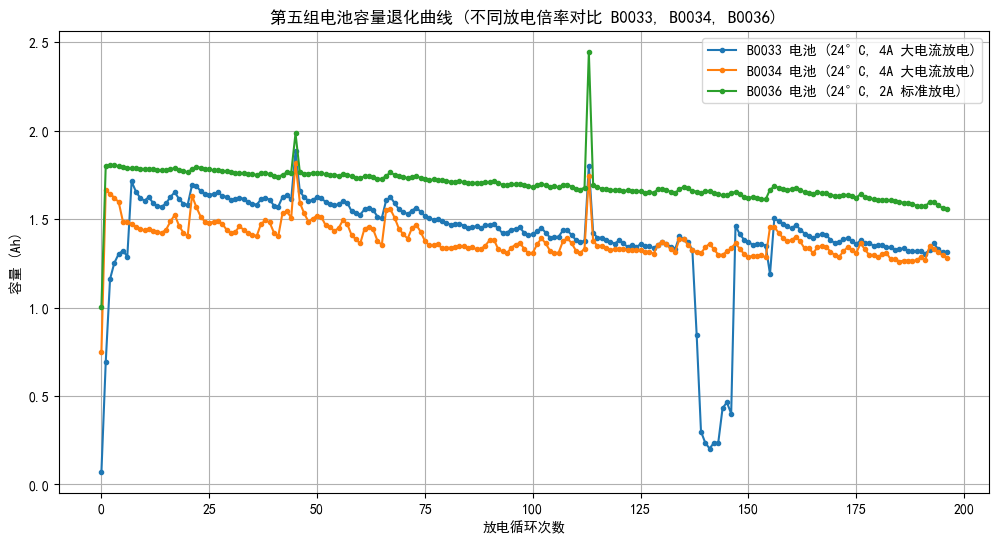

In [33]:
import os
import matplotlib.pyplot as plt

# 依旧是第 3 个文件夹路径
folder_path_group3 = r'../data/raw/3. BatteryAgingARC_25-44'

# 目标电池：注意没有 35 号
target_batteries_rate = ['B0033.mat', 'B0034.mat', 'B0036.mat']

plt.figure(figsize=(12, 6))

for file_name in target_batteries_rate:
    file_path = os.path.join(folder_path_group3, file_name)
    
    if os.path.exists(file_path):
        batt_name, caps = extract_capacity(file_path)
        
        # 为了图例更清晰，我们可以加个判断
        if batt_name == 'B0036':
            label_text = f'{batt_name} 电池 (24°C, 2A 标准放电)'
        else:
            label_text = f'{batt_name} 电池 (24°C, 4A 大电流放电)'
            
        plt.plot(caps, marker='.', label=label_text)
    else:
        print(f"警告：找不到文件 {file_name}")

plt.title('第五组电池容量退化曲线 (不同放电倍率对比 B0033, B0034, B0036)')
plt.xlabel('放电循环次数')
plt.ylabel('容量 (Ah)')
plt.legend()
plt.grid(True)
plt.show()

### 38-40号电池环境

一组由三个锂离子电池（#38、#39 和 #40）组成的电池在 **24°C 和 44°C** 两种环境温度下进行了三种不同运行工况的测试，包括充电、放电以及阻抗测量。充电过程首先采用 **恒流（CC）模式**，以 **1.5A** 的电流进行充电，直到电池电压达到 **4.2V**；随后转入 **恒压（CV）模式**，并持续充电，直到充电电流下降到 **20mA** 为止。

在放电测试中，实验使用了 **1A、2A 和 4A** 三种不同的负载电流。不同电池的放电终止电压分别为：电池 **38** 的截止电压为 **2.2V**，电池 **39** 为 **2.5V**，电池 **40** 为 **2.7V**。此外，实验还进行了阻抗测量，通过 **电化学阻抗谱（EIS）** 方法，在 **0.1Hz 至 5kHz** 的频率范围内进行频率扫描。

整个实验持续进行，直到电池容量下降到 **1.6Ah**（即容量衰减 **20%**）为止。


文档强调了“部分循环中容量极低且原因未完全分析” 。
在 $T = 4°C$ 时，电池的扩散系数 $D$ 大幅下降：
$$D = D_0 \exp(-\frac{E_d}{k_B T})$$
这会导致严重的极化现象。说明这是由于低温导致析锂 (Lithium Plating) 引起的非典型失效。

Text(0, 0.5, '容量 (Ah)')

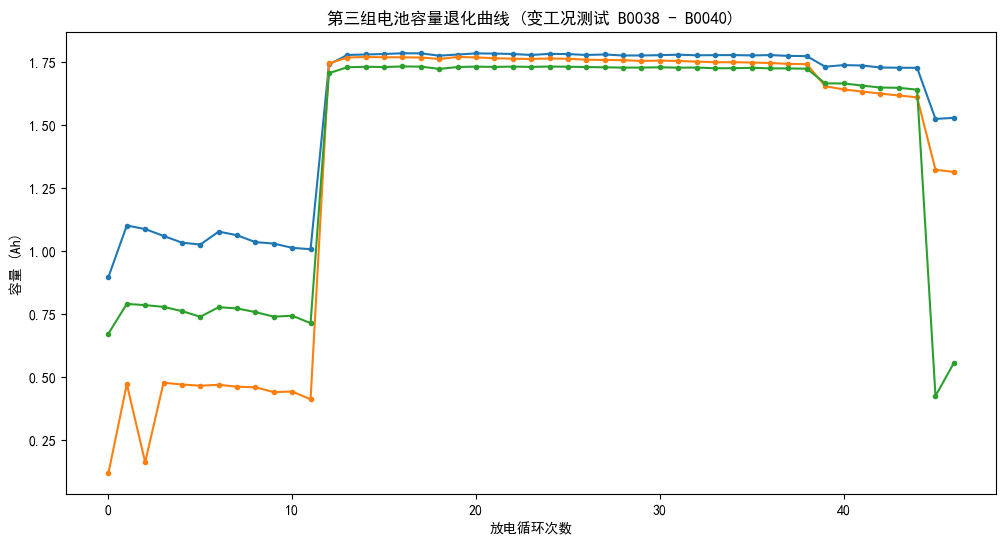

In [31]:
import os
import matplotlib.pyplot as plt

# 依然是第 3 个文件夹路径
folder_path_group3 = r'../data/raw/3. BatteryAgingARC_25-44'

# 定义这组“变工况”电池的编号
target_batteries_dynamic = ['B0038.mat', 'B0039.mat', 'B0040.mat']

plt.figure(figsize=(12, 6))

for file_name in target_batteries_dynamic:
    file_path = os.path.join(folder_path_group3, file_name)
    
    if os.path.exists(file_path):
        batt_name, caps = extract_capacity(file_path)
        plt.plot(caps, marker='.', label=f'{batt_name} 电池 (变温度/变电流)')
    else:
        print(f"警告：找不到文件 {file_name}")

plt.title('第三组电池容量退化曲线 (变工况测试 B0038 - B0040)')
plt.xlabel('放电循环次数')
plt.ylabel('容量 (Ah)')

### 41-44号电池数据分析

一组四个锂离子电池（#41–44）在 **4°C 的环境温度** 下进行了三种不同运行工况的测试，包括充电、放电以及阻抗测量。充电过程首先采用 **恒流（CC）模式**，以 **1.5A** 的电流进行充电，直到电池电压达到 **4.2V**；随后转入 **恒压（CV）模式**，并持续充电，直到充电电流下降到 **20mA** 为止。

在放电测试中，实验使用了 **4A 和 1A** 两种固定负载电流。不同电池的放电终止电压有所不同：电池 **41** 的截止电压为 **2V**，电池 **42** 为 **2.2V**，电池 **43** 为 **2.5V**，电池 **44** 为 **2.7V**。此外，实验还进行了阻抗测量，通过 **电化学阻抗谱（EIS）** 方法，在 **0.1Hz 到 5kHz** 的频率范围内进行频率扫描。

整个实验持续进行，直到电池容量下降至 **1.4Ah**（即容量衰减 **30%**）为止。需要注意的是，在部分放电实验中测得的容量非常低，其具体原因目前尚未得到充分分析。


文档再次强调了“部分循环中容量极低且原因未完全分析” 。
在 $T = 4°C$ 时，电池的扩散系数 $D$ 大幅下降：
$$D = D_0 \exp(-\frac{E_d}{k_B T})$$
这会导致严重的极化现象。

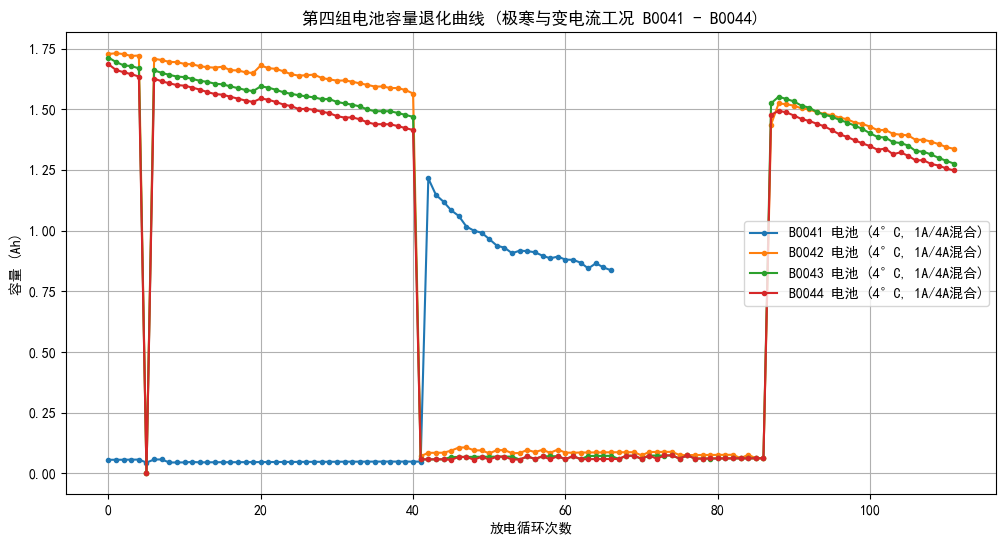

In [32]:
import os
import matplotlib.pyplot as plt

# 依然是第 3 个文件夹路径
folder_path_group3 = r'../data/raw/3. BatteryAgingARC_25-44'

# 定义这组“极寒+变工况”电池的编号
target_batteries_low_temp = ['B0041.mat', 'B0042.mat', 'B0043.mat', 'B0044.mat']

plt.figure(figsize=(12, 6))

for file_name in target_batteries_low_temp:
    file_path = os.path.join(folder_path_group3, file_name)
    
    # 检查文件是否存在
    if os.path.exists(file_path):
        # 调用我们之前写好的 extract_capacity 函数
        batt_name, caps = extract_capacity(file_path)
        plt.plot(caps, marker='.', label=f'{batt_name} 电池 (4°C, 1A/4A混合)')
    else:
        print(f"警告：找不到文件 {file_name}")

plt.title('第四组电池容量退化曲线 (极寒与变电流工况 B0041 - B0044)')
plt.xlabel('放电循环次数')
plt.ylabel('容量 (Ah)')
plt.legend()
plt.grid(True)
plt.show()

## 第四组电池数据分析

一组由四个锂离子电池（#45–48）组成的电池在 4°C 的环境温度 下进行了三种不同运行工况的测试，包括充电、放电以及阻抗测量。充电过程首先采用 恒流（CC）模式，以 1.5A 的电流进行充电，直到电池电压达到 4.2V；随后转入 恒压（CV）模式，并持续充电，直到充电电流下降至 20mA 为止。

在放电测试中，实验使用了 1A 的固定负载电流。不同电池的放电终止电压分别为：电池 45 的截止电压为 2V，电池 46 为 2.2V，电池 47 为 2.5V，电池 48 为 2.7V。此外，实验还进行了阻抗测量，通过 电化学阻抗谱（EIS） 方法，在 0.1Hz 至 5kHz 的频率范围内进行频率扫描。

整个实验持续进行，直到电池容量下降至 1.4Ah（即容量衰减 30%）为止。需要注意的是，在部分放电实验中测得的容量非常低，其具体原因目前尚未得到充分分析。

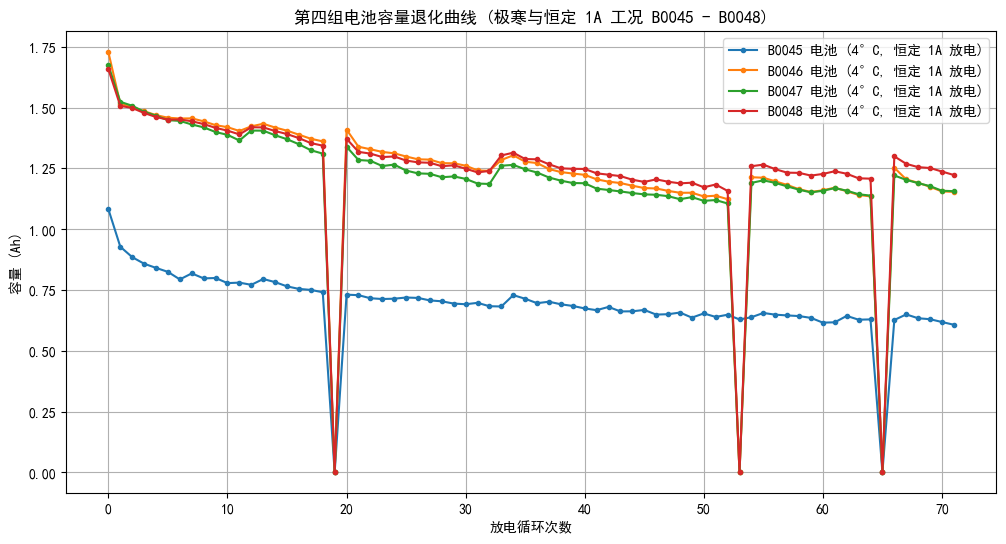

In [44]:
import os
import matplotlib.pyplot as plt

# 指向第 4 个文件夹路径 (根据你之前的截图，应该是这个名字)
folder_path_group4 = r'../data/raw/4. BatteryAgingARC_45_46_47_48'

# 定义这组“极寒+恒定小电流”电池的编号
target_batteries_fixed_low = ['B0045.mat', 'B0046.mat', 'B0047.mat', 'B0048.mat']

plt.figure(figsize=(12, 6))

for file_name in target_batteries_fixed_low:
    file_path = os.path.join(folder_path_group4, file_name)
    
    # 检查文件是否存在
    if os.path.exists(file_path):
        batt_name, caps = extract_capacity(file_path)
        plt.plot(caps, marker='.', label=f'{batt_name} 电池 (4°C, 恒定 1A 放电)')
    else:
        print(f"警告：找不到文件 {file_name}")

plt.title('第四组电池容量退化曲线 (极寒与恒定 1A 工况 B0045 - B0048)')
plt.xlabel('放电循环次数')
plt.ylabel('容量 (Ah)')
plt.legend()
plt.grid(True)
plt.show()

## 第五组电池数据分析

一组由四个锂离子电池（#49–52）组成的电池在 4°C 的环境温度 下进行了三种不同运行工况的测试，包括充电、放电以及阻抗测量。充电过程首先采用 恒流（CC）模式，以 1.5A 的电流进行充电，直到电池电压达到 4.2V；随后转入 恒压（CV）模式，并持续充电，直到充电电流下降至 20mA 为止。

在放电测试中，实验使用了 2A 的固定负载电流。不同电池的放电终止电压分别为：电池 49 的截止电压为 2V，电池 50 为 2.2V，电池 51 为 2.5V，电池 52 为 2.7V。此外，实验还进行了阻抗测量，通过 电化学阻抗谱（EIS） 方法，在 0.1Hz 至 5kHz 的频率范围内进行频率扫描。

实验一直持续进行，直到 实验控制软件发生崩溃 为止。需要注意的是，在部分放电实验中测得的 容量以及电压水平都非常低，其具体原因目前尚未得到充分分析。

脏数据B0050 在索引 52 处的容量记录为空
脏数据B0050 在索引 54 处的容量记录为空
脏数据B0050 在索引 56 处的容量记录为空
脏数据B0050 在索引 58 处的容量记录为空
脏数据B0052 在索引 10 处的容量记录为空
脏数据B0052 在索引 14 处的容量记录为空
脏数据B0052 在索引 16 处的容量记录为空
脏数据B0052 在索引 18 处的容量记录为空
脏数据B0052 在索引 20 处的容量记录为空
脏数据B0052 在索引 22 处的容量记录为空
脏数据B0052 在索引 26 处的容量记录为空
脏数据B0052 在索引 28 处的容量记录为空
脏数据B0052 在索引 30 处的容量记录为空
脏数据B0052 在索引 32 处的容量记录为空
脏数据B0052 在索引 34 处的容量记录为空
脏数据B0052 在索引 38 处的容量记录为空
脏数据B0052 在索引 40 处的容量记录为空
脏数据B0052 在索引 42 处的容量记录为空
脏数据B0052 在索引 44 处的容量记录为空
脏数据B0052 在索引 46 处的容量记录为空
脏数据B0052 在索引 50 处的容量记录为空
脏数据B0052 在索引 52 处的容量记录为空
脏数据B0052 在索引 54 处的容量记录为空
脏数据B0052 在索引 56 处的容量记录为空
脏数据B0052 在索引 58 处的容量记录为空


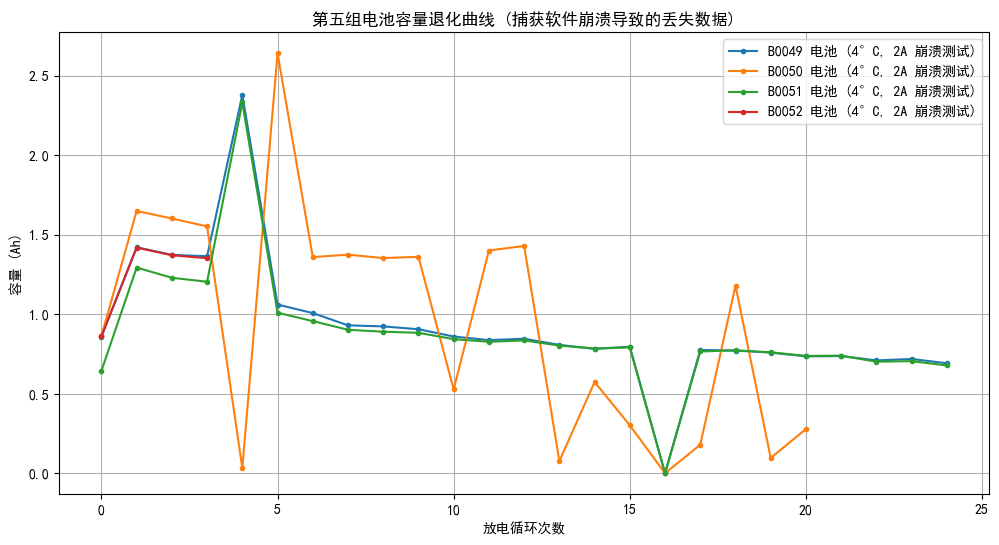

In [47]:
import os
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 

def extract_capacity_robust(file_path):
    mat_data = scipy.io.loadmat(file_path)
    battery_name = [k for k in mat_data.keys() if not k.startswith('__')][0]
    battery_data = mat_data[battery_name]
    cycles = battery_data[0, 0]['cycle'][0]
    
    capacities = []
    for i in range(len(cycles)):
        if cycles[i]['type'][0] == 'discharge':
            data_struct = cycles[i]['data'][0, 0]
            
            # 核心修复：添加 try-except 来对付软件崩溃导致的空数据
            try:
                cap = data_struct['Capacity'][0, 0]
                capacities.append(cap)
            except IndexError:
                # 抓到空数据！打印出来看看是哪个倒霉蛋，并用 NaN 占位
                print(f"脏数据{battery_name} 在索引 {i} 处的容量记录为空")
                capacities.append(np.nan) 
                
    return battery_name, capacities

# --- 绘图主逻辑 ---
folder_path_group5 = r'../data/raw/5. BatteryAgingARC_49_50_51_52'
target_batteries_crash = ['B0049.mat', 'B0050.mat', 'B0051.mat', 'B0052.mat']

plt.figure(figsize=(12, 6))

for file_name in target_batteries_crash:
    file_path = os.path.join(folder_path_group5, file_name)
    
    if os.path.exists(file_path):
        batt_name, caps = extract_capacity_robust(file_path)
        plt.plot(caps, marker='.', label=f'{batt_name} 电池 (4°C, 2A 崩溃测试)')
    else:
        print(f"警告：找不到文件 {file_name}")

plt.title('第五组电池容量退化曲线 (捕获软件崩溃导致的丢失数据)')
plt.xlabel('放电循环次数')
plt.ylabel('容量 (Ah)')
plt.legend()
plt.grid(True)
plt.show()

## 第六组电池数据分析

一组由四个锂离子电池（#53–56）组成的电池在 **4°C 的环境温度** 下进行了三种不同运行工况的测试，包括充电、放电以及阻抗测量。充电过程首先采用 **恒流（CC）模式**，以 **1.5A** 的电流进行充电，直到电池电压达到 **4.2V**；随后转入 **恒压（CV）模式**，并持续充电，直到充电电流下降至 **20mA** 为止。

在放电测试中，实验使用了 **2A 的固定负载电流**。不同电池的放电终止电压分别为：电池 **53** 的截止电压为 **2V**，电池 **54** 为 **2.2V**，电池 **55** 为 **2.5V**，电池 **56** 为 **2.7V**。此外，实验还进行了阻抗测量，通过 **电化学阻抗谱（EIS）** 方法，在 **0.1Hz 至 5kHz** 的频率范围内进行频率扫描。

整个实验持续进行，直到电池容量下降至 **1.4Ah**（即容量衰减 **30%**）为止。需要注意的是，在部分放电实验中测得的容量非常低，其具体原因目前尚未得到充分分析。


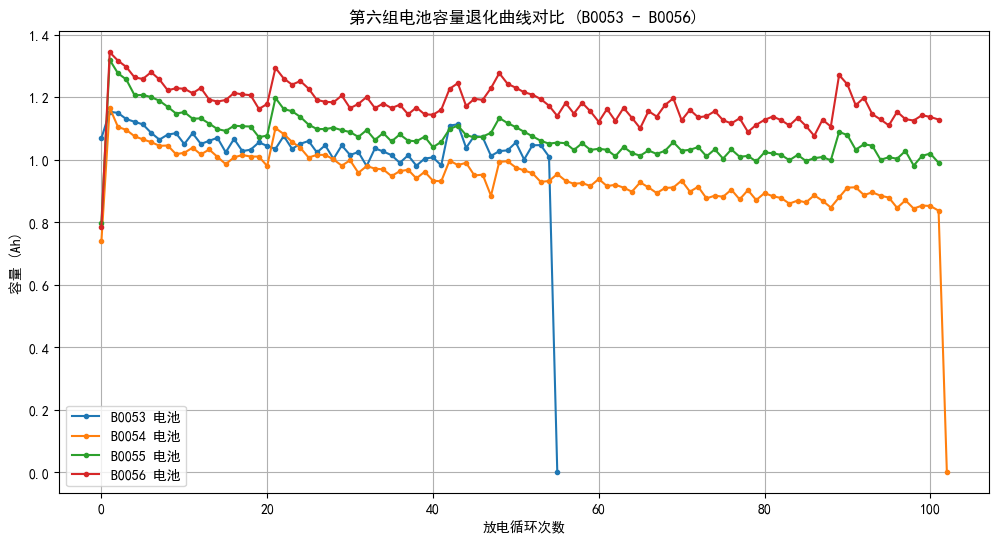

In [28]:
# 只需要把路径指向第 6 组的文件夹
folder_path_group6 = r'../data/raw/6. BatteryAgingARC_53_54_55_56'

plt.figure(figsize=(12, 6))

# 遍历第 6 组文件夹里的每一个文件
for file_name in os.listdir(folder_path_group6):
    # 只处理 .mat 文件，自动跳过那个 README.txt
    if file_name.endswith('.mat'):
        file_path = os.path.join(folder_path_group6, file_name)
        
        # 直接调用我们写好的神仙函数
        batt_name, caps = extract_capacity(file_path)
        
        # 画入图中
        plt.plot(caps, marker='.', label=f'{batt_name} 电池')

plt.title('第六组电池容量退化曲线对比 (B0053 - B0056)')
plt.xlabel('放电循环次数')
plt.ylabel('容量 (Ah)')
plt.legend()
plt.grid(True)
plt.show()